In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [5]:
gen=df["gender"]
encoder=LabelEncoder()
gen_encoded=encoder.fit_transform(gen)
print(gen_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[0 1 1 ... 0 1 1]
Mapping {'Female': 0, 'Male': 1}


In [6]:
IS=df["InternetService"]
encoder=LabelEncoder()
IS_encoded=encoder.fit_transform(IS)
print(IS_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[0 0 0 ... 0 1 1]
Mapping {'DSL': 0, 'Fiber optic': 1, 'No': 2}


In [7]:
contract=df["Contract"]
encoder=LabelEncoder()
contract_encoded=encoder.fit_transform(contract)
print(contract_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[0 1 0 ... 0 0 2]
Mapping {'Month-to-month': 0, 'One year': 1, 'Two year': 2}


In [8]:
PM=df["PaymentMethod"]
encoder=LabelEncoder()
PM_encoded=encoder.fit_transform(PM)
print(PM_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[2 3 3 ... 2 3 0]
Mapping {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}


In [9]:
churn=df["Churn"]
encoder=LabelEncoder()
churn_encoded=encoder.fit_transform(churn)
print(churn_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[0 0 1 ... 0 1 0]
Mapping {'No': 0, 'Yes': 1}


## Machine Learning 

In [13]:
from sklearn.model_selection import train_test_split
x=df1.drop("Churn",axis=1)
y=df1["Churn"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Training set size:",x_train.shape)
print("Test set size:",x_test.shape)
print("Churn distribution in Train:\n",y_train.value_counts(normalize=True))
print("Churn distribution in test:\n",y_test.value_counts(normalize=True))

Training set size: (5634, 20)
Test set size: (1409, 20)
Churn distribution in Train:
 Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn distribution in test:
 Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [11]:
df1=df.copy()

In [19]:
x_train = x_train.drop(columns=['customerID'])
x_test = x_test.drop(columns=['customerID'])


In [23]:
import pandas as pd
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay,accuracy_score
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:,1]


In [25]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.7934705464868701


In [26]:
print("Classification report:\n",classification_report(y_test,y_pred))

Classification report:
               precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



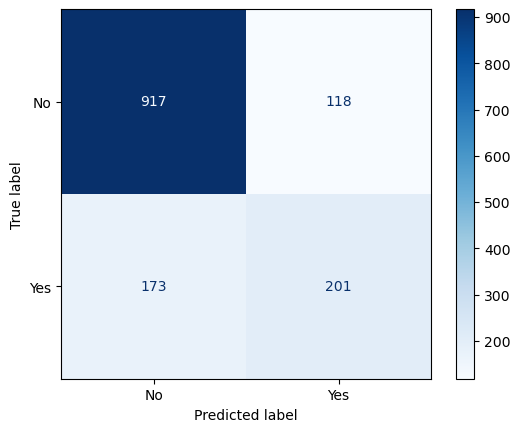

In [27]:
ConfusionMatrixDisplay.from_estimator(log_reg,x_test,y_test,cmap="Blues")

In [28]:
print("ROC-AUC score:",roc_auc_score(y_test,y_prob))

ROC-AUC score: 0.8403239556692242


In [32]:
y_train = y_train.map({'No':0, 'Yes':1})
y_test = y_test.map({'No':0, 'Yes':1})


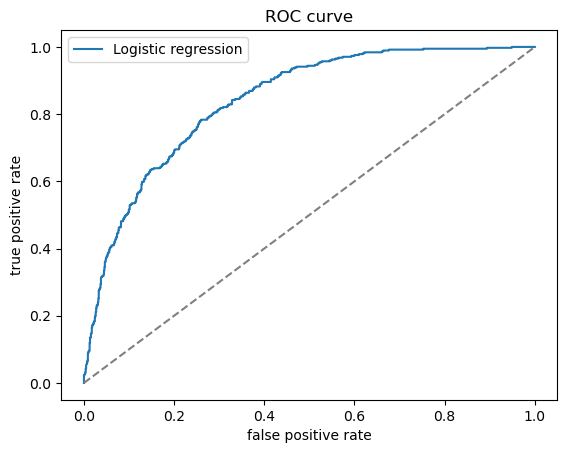

In [39]:
from sklearn.metrics import roc_curve

fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Logistic regression")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()